Data Preparation

In [55]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
import time
from IPython.display import display, clear_output, Markdown

# --- 1. Setup and Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. Define the Target System (Swiss Roll via KDE) ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# Assuming 'device' is defined in your global scope, otherwise set it:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Temperature_Training = 1.0
Temperature_Sampling = 1.0

class SwissRollEnergy:
    """
    Defines the target energy U_ref based on the Swiss Roll dataset.
    Uses Kernel Density Estimation (KDE) to create a continuous energy landscape.
    """
    def __init__(self, n_samples=5000, noise=0.1, bandwidth=0.3):
        self.n_samples = n_samples
        self.init_bandwidth = bandwidth

        # 1. Generate Swiss Roll Data once
        X, _ = make_swiss_roll(n_samples=n_samples, noise=noise)
        X = X[:, [0, 2]] / 3.0  # Project to 2D (x, z) and scale
        self.ref_data = torch.tensor(X, dtype=torch.float32).to(device)

        # Storage for the intermediate landscape parameters
        # Dictionary format: {t: {'data': centers, 'bw': bandwidth, 'norm': const}}
        self.snapshots = {}

        # Initialize t=0 snapshot (The original data)
        self._store_snapshot(0.0, self.ref_data, self.init_bandwidth)

    def _store_snapshot(self, t, centers, bandwidth):
        """Helper to store parameters for a specific time t"""
        log_norm = -np.log(self.n_samples) - np.log(2 * np.pi * bandwidth**2)
        self.snapshots[t] = {
            'data': centers,
            'bandwidth': bandwidth,
            'log_norm': log_norm
        }

    def potential_energy(self, x_query, t=0.0):
        """
        Calculates U(x) using the KDE parameters specific to time t.
        If t is not stored, it defaults to t=0.
        """
        # Retrieve snapshot parameters (find closest stored time if needed, here exact match)
        snap = self.snapshots.get(t, self.snapshots[0.0])

        ref_data = snap['data']
        bw = snap['bandwidth']
        log_norm = snap['log_norm']

        # Broadcasting for KDE calculation
        x_expanded = x_query.unsqueeze(1)    # (B, 1, 2)
        ref_expanded = ref_data.unsqueeze(0) # (1, N, 2)

        # Squared Euclidean distance
        dists = torch.sum((x_expanded - ref_expanded)**2, dim=2)

        # Log-Sum-Exp trick
        log_densities = -dists / (2 * bw**2)
        log_p = torch.logsumexp(log_densities, dim=1) + log_norm

        return -log_p.unsqueeze(1)

    def calculate_snapshots(self, f_func, g_func, times=[0, 0.4, 0.8], dt=0.001):
        """
        Numerically calculates the energy landscapes at specified times.
        It integrates f (drift) and g (diffusion) to find how the KDE centers
        shift and how the KDE bandwidth widens.
        """
        print(f"Computing energy landscapes for times: {times}...")

        # Sort times to integrate sequentially
        times = sorted(times)

        # Simulation state
        current_t = 0.0

        # We track how a single "test particle" at x=1.0 evolves to determine Mean Scaling
        mean_scale = 1.0

        # We track accumulated variance from the noise g(t)
        var_accum = 0.0

        for t_target in times:
            if t_target == 0:
                continue

            # Numerical Integration (Euler method) from current_t to t_target
            while current_t < t_target:
                # 1. Integrate Drift Scaling
                # We probe f at (mean_scale, t) to see how the signal decays
                # Assumptions: f is linear in x (standard for diffusion models)
                x_probe = torch.tensor([mean_scale], device=device).float()
                t_probe = torch.tensor([current_t], device=device).float()

                drift = f_func(x_probe, t_probe).item() # returns dx/dt
                mean_scale += drift * dt

                # 2. Integrate Noise Variance
                # Variance grows by g(t)^2 * dt
                g_val = g_func(t_probe).item()
                var_accum += (g_val**2) * dt

                current_t += dt

            # Calculate new KDE parameters for this time t

            # The centers of the Gaussians move according to the drift (mean_scale)
            new_centers = self.ref_data * mean_scale

            # The bandwidth consists of the original bandwidth (scaled down if space shrinks)
            # plus the accumulated noise variance.
            # Variance_new = (Scale * sigma_old)^2 + Accumulated_Noise_Var
            new_bandwidth = np.sqrt((mean_scale * self.init_bandwidth)**2 + var_accum)

            # Store it
            self._store_snapshot(t_target, new_centers, new_bandwidth)
            print(f"  t={t_target:.2f}: Mean Scale={mean_scale:.3f}, New Bandwidth={new_bandwidth:.3f}")

    def plot_evolution(self, times=[0, 0.4, 0.8]):
        """
        Plots the energy landscape contours for the requested times.
        """
        # Create Grid
        limit = 4.0
        grid_size = 100
        x = np.linspace(-limit, limit, grid_size)
        y = np.linspace(-limit, limit, grid_size)
        xx, yy = np.meshgrid(x, y)
        grid_tensor = torch.tensor(np.stack([xx, yy], axis=-1), dtype=torch.float32).view(-1, 2).to(device)

        fig, axes = plt.subplots(1, len(times), figsize=(6 * len(times), 5))
        if len(times) == 1: axes = [axes]

        for i, t in enumerate(times):
            if t not in self.snapshots:
                print(f"Warning: t={t} not computed yet. Skipping.")
                continue

            # Compute Energy
            with torch.no_grad():
                energy = self.potential_energy(grid_tensor, t=t)
                energy = energy.view(grid_size, grid_size).cpu().numpy()

            # Plot
            ax = axes[i]
            # Clip very high energy values for better visualization contrast
            energy = np.clip(energy, a_min=None, a_max=10)

            cp = ax.contourf(xx, yy, energy, levels=50, cmap='viridis_r')
            fig.colorbar(cp, ax=ax, label='Energy U(x)')
            ax.set_title(f"Energy Landscape at t={t}")
            ax.set_aspect('equal')
            ax.set_xlim(-limit, limit)
            ax.set_ylim(-limit, limit)

        plt.tight_layout()
        plt.show()


def plot_dataset_and_energy(target_system, device, title="Target System: Data vs Energy"):
    """
    Plots the reference dataset (Swiss Roll) and the calculated Kernel Density Energy landscape.
    """
    # 1. Get Reference Data (The "Ground Truth" Points)
    # Move to CPU for plotting
    ref_data = target_system.ref_data.cpu().numpy()

    # 2. Create a Grid to evaluate the Energy Function
    # We want to see the continuous landscape U(x)
    grid_size = 200
    range_lim = 4.0
    x = np.linspace(-range_lim, range_lim, grid_size)
    y = np.linspace(-range_lim, range_lim, grid_size)
    xx, yy = np.meshgrid(x, y)

    # Flatten grid for batch processing
    grid_tensor = torch.tensor(np.column_stack((xx.ravel(), yy.ravel())), dtype=torch.float32).to(device)

    # 3. Calculate Energy on Grid
    # U(x) = -log(KDE(x))
    with torch.no_grad():
        # This might be heavy for one batch, so we can chunk if needed,
        # but 40k points fits easily on most GPUs.
        energies = target_system.potential_energy(grid_tensor)

    # Reshape back to grid for contour plotting
    u_grid = energies.cpu().numpy().reshape(grid_size, grid_size)

    # 4. Plotting
    plt.figure(figsize=(10, 8))

    # A) Plot the Energy Contours (The "Potential Well")
    # We clip the high energy values for better visualization contrast
    # (High energy = low probability, which we care less about)
    contour = plt.contourf(xx, yy, u_grid, levels=50, cmap='viridis', vmin=np.min(u_grid), vmax=np.min(u_grid) + 10)
    cbar = plt.colorbar(contour)
    cbar.set_label('Potential Energy U(x)')

    # B) Plot the Data Points (The "Samples")
    # These should sit perfectly inside the dark blue valleys of the energy plot
    plt.scatter(ref_data[:, 0], ref_data[:, 1], s=1, c='white', alpha=0.15, label='Reference Data')

    plt.title(title, fontsize=14)
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend(loc='upper right')
    plt.xlim(-range_lim, range_lim)
    plt.ylim(-range_lim, range_lim)
    plt.grid(False) # Grid lines can be distracting on contour plots
    plt.show()

def plot_loss_curve(loss_history, title='Training Loss Curve', xlabel='Epoch', ylabel='Loss'):
    """
    Plots a loss curve from a list/array of loss values.

    Args:
        loss_history (list or np.array): A list or array containing loss values for each epoch.
        title (str): The title of the plot.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, label='Loss')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.show()

# --- 3. The Model (2D Spatial + 1D Time) ---

# class ScoreNet(nn.Module):
#     """
#     Network outputting:
#     1. Force F(x,t) (Vector, 2D)
#     2. Energy u(x,t) (Scalar, 1D)
#     """
#     def __init__(self):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(3, 256), # Input: x, y, t
#             nn.Tanh(),
#             nn.Linear(256, 256),
#             nn.Tanh(),
#             nn.Linear(256, 128),
#             nn.Tanh(),
#             nn.Linear(128, 3) # Output: [Fx, Fy, Energy]
#         )

#     def forward(self, x, t):
#         # x is (Batch, 2), t is (Batch, 1)
#         xt = torch.cat([x, t], dim=1)
#         output = self.net(xt)

#         force = output[:, :2]  # Fx, Fy
#         energy = output[:, 2:] # u
#         return force, energy





Using device: cuda


Models

In [56]:
class SinusoidalTimeEmbeddings(nn.Module):
    """
    Creates a high-dimensional vector representation of the scalar time t.
    Standard in Diffusion Models (Vaswani et al. / Ho et al.).
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class TimeAwareResBlock(nn.Module):
    """
    A Residual Block that takes both input features x and time embeddings t_emb.
    Structure:
    x -> [Linear -> SiLU -> Linear] + x
               ^
               | (Added here)
           Time Projection
    """
    def __init__(self, dim, time_emb_dim):
        super().__init__()
        self.act = nn.SiLU()
        self.linear1 = nn.Linear(dim, dim)
        self.linear2 = nn.Linear(dim, dim)

        # Projection to map time embedding dimension to feature dimension
        self.time_proj = nn.Linear(time_emb_dim, dim)

        # Normalization (LayerNorm is usually good for simple MLPs)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x, t_emb):
        h = self.linear1(self.act(self.norm(x)))

        # Inject time info: Add projected time embedding to hidden features
        # This modulates the features based on the noise level t
        h = h + self.time_proj(self.act(t_emb))

        h = self.linear2(self.act(h))

        # Residual connection
        return x + h

class ScoreNet(nn.Module):
    """
    Improved Architecture:
    1. Force F(x,t) (Vector, 2D)
    2. Energy u(x,t) (Scalar, 1D)
    """
    def __init__(self, input_dim=2, hidden_dim=128, time_emb_dim=64, num_layers=3):
        super().__init__()

        # 1. Feature Embeddings
        # Projects 2D input (x,y) to hidden dimension
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # 2. Time Embeddings
        # Projects scalar t to high-dim vector
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # 3. Main Backbone (Stacked ResBlocks)
        self.blocks = nn.ModuleList([
            TimeAwareResBlock(hidden_dim, time_emb_dim)
            for _ in range(num_layers)
        ])

        # 4. Final Norm & Activation
        self.final_norm = nn.LayerNorm(hidden_dim)
        self.final_act = nn.SiLU()

        # 5. Output Heads
        # We separate the heads for Force and Energy for better disentanglement,
        # but output them together to match your requested API.
        self.head_force = nn.Linear(hidden_dim, 2)  # Fx, Fy
        self.head_energy = nn.Linear(hidden_dim, 1) # Energy

    def forward(self, x, t):
        # x is (Batch, 2), t is (Batch, 1) or (Batch,)

        # Ensure t is correct shape (Batch, 1)
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        # --- Embeddings ---
        # 1. Embed time
        t_emb = self.time_mlp(t) # (Batch, time_emb_dim)

        # 2. Embed input
        h = self.input_proj(x)   # (Batch, hidden_dim)

        # --- Backbone ---
        # Pass through residual blocks, injecting time at each step
        for block in self.blocks:
            h = block(h, t_emb)

        # Final processing
        h = self.final_act(self.final_norm(h))

        # --- Outputs ---
        force = self.head_force(h)   # (Batch, 2)
        energy = self.head_energy(h) # (Batch, 1)

        return force, energy


class FlowNet(nn.Module):
    """
    Flow Matching Network.
    Outputs:
    1. Velocity v(x,t) (Vector, 2D) - Used for ODE sampling
    2. Energy u(x,t) (Scalar, 1D)   - Used to enforce physics constraints
    """
    def __init__(self, input_dim=2, hidden_dim=128, time_emb_dim=64, num_layers=3):
        super().__init__()
        
        # 1. Embeddings
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # 2. Backbone
        self.blocks = nn.ModuleList([
            TimeAwareResBlock(hidden_dim, time_emb_dim)
            for _ in range(num_layers)
        ])

        # 3. Heads
        self.final_norm = nn.LayerNorm(hidden_dim)
        self.final_act = nn.SiLU()
        
        # Output Heads
        self.head_velocity = nn.Linear(hidden_dim, 2)  # v (Velocity)
        self.head_energy = nn.Linear(hidden_dim, 1)    # U (Energy)

    def forward(self, x, t):
        if t.dim() == 1: t = t.unsqueeze(-1)
        
        t_emb = self.time_mlp(t)
        h = self.input_proj(x)
        
        for block in self.blocks:
            h = block(h, t_emb)
            
        h = self.final_act(self.final_norm(h))
        
        velocity = self.head_velocity(h)
        energy = self.head_energy(h)
        
        return velocity, energy

Diffusion Coefficients

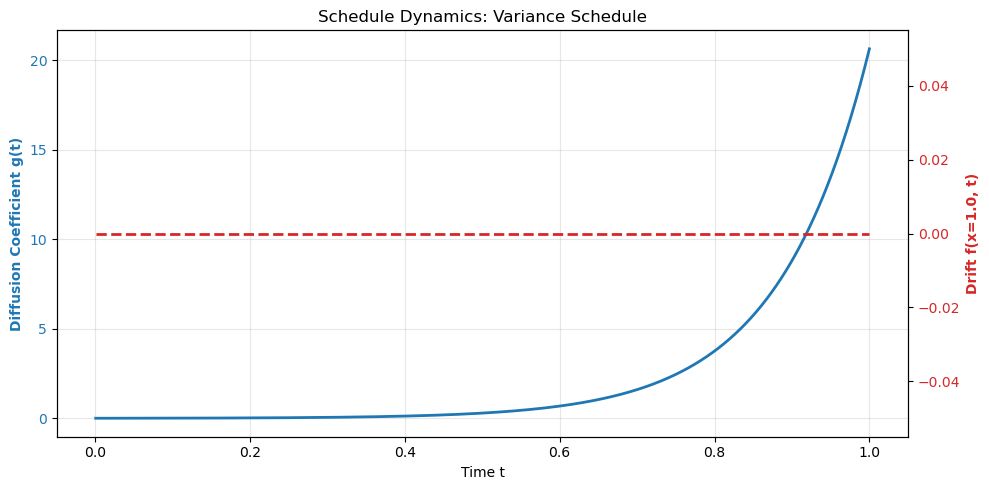

In [57]:

# --- 4. SDE Coefficients ---

# --- 1. Variance Exploding (VE) SDE ---
# "The Geometric Schedule"
# Used in: Song et al. "Generative Modeling by Estimating Gradients of the Data Distribution" (NCSN)
# Description: Drift is zero. The signal is not scaled down, noise is just added on top until it explodes.
# Good for: Robustness, separation of scales.

sigma_min = 0.001
sigma_max = 5.0

def f_xt(x, t):
    # Drift is zero for VE-SDE
    return x * 0

def g_t(t):
    # g(t) = sigma(t) * sqrt(2 * (log(sigma_max) - log(sigma_min)))
    # This ensures the marginal distribution is roughly N(x, sigma(t)^2)
    sigma_t = sigma_min * (sigma_max / sigma_min) ** t
    return sigma_t * torch.sqrt(torch.tensor(2 * (np.log(sigma_max) - np.log(sigma_min))))


# --- 2. Variance Preserving (VP) SDE ---
# "The Linear Schedule"
# Used in: Ho et al. "Denoising Diffusion Probabilistic Models" (DDPM)
# Description: As noise is added, the signal is scaled down (-0.5*beta*x).
# The total variance of the data + noise remains fixed at 1.
# Good for: Image stability, bounding the values.

# beta_min = 0.1
# beta_max = 5.0

# def beta_t(t):
#     return beta_min + t * (beta_max - beta_min)

# def f_xt(x, t):
#     # Drift: -1/2 * beta(t) * x
#     # This pulls the data back toward 0 to counteract the added variance
#     beta = beta_t(t)
#     if hasattr(beta, "view"): beta = beta.view(-1, 1) # Handle broadcasting if t is a batch
#     return -0.5 * beta * x

# def g_t(t):
#     # Diffusion: sqrt(beta(t))
#     beta = beta_t(t)
#     return torch.sqrt(beta)


# --- 3. Simple Brownian Motion (Your original) ---
# "The Exploding Linear Variance"
# Description: Variance grows linearly with t. Simple but rarely used for complex images
# because variance doesn't grow fast enough to wipe out structure efficiently at t=1.

# def f_xt(x, t):
#     return x * 0

# def g_t(t):
#     return torch.sqrt(2 * t)


# --- 4. Sub-VP SDE ---
# Description: Similar to VP but the variance is bounded even tighter.
# Often produces better likelihoods but worse sample quality than VE/VP.

# beta_min = 0.1
# beta_max = 20.0

# def beta_t(t):
#     return beta_min + t * (beta_max - beta_min)

# def f_xt(x, t):
#     beta = beta_t(t)
#     if hasattr(beta, "view"): beta = beta.view(-1, 1)
#     return -0.5 * beta * x

# def g_t(t):
#     # The diffusion coefficient is discounted by the accumulated decay
#     # This is complex to implement analytically without an integral helper,
#     # but this is the simplified form often used in code:
#     beta = beta_t(t)
#     discount = 1 - torch.exp(-2 * t * beta) # Simplified approximation for illustration
#     return torch.sqrt(beta * discount)


# --- 5. Linear Interpolation Schedule (Rectified Flow) ---
# Used in: Flow Matching, Rectified Flow, InstaFlow
# Description: The path is a straight line interpolation: x_t = (1-t)x_0 + t*epsilon
# Advantages: Perfectly straight trajectories, compatible with Minibatch OT.
# Note: This schedule has a singularity at t=1 (pure noise), so typically
# solvers integrate up to t=0.999 or use the ODE formulation directly.

# def f_xt(x, t):
#     """
#     Drift for Linear Interpolation (Rectified Flow).
#     This forces the mean to scale as (1-t).
#     Mathematically derived from d(mean)/dt = f * mean.
#     """
#     # Singularity check: At t=1, the drift explodes to force x to 0.
#     # We clamp t to 0.999 to avoid division by zero.
#     t_safe = torch.clamp(t, max=0.999)
#     if x.ndim > 1 and t_safe.ndim == 1:
#         t_safe = t_safe.view(-1, 1)

#     # f(x,t) = -1 / (1-t) * x
#     return -1.0 / (1.0 - t_safe) * x

# def g_t(t):
#     """
#     Diffusion for Linear Interpolation.
#     Combined with the drift above, this forces Variance = t^2.
#     """
#     t_safe = torch.clamp(t, max=0.999)
    
#     # g(t) = sqrt( 2t / (1-t) )
#     return torch.sqrt(2 * t_safe / (1.0 - t_safe))


def plot_schedule_dynamics(f_xt_func, g_t_func, label, x_val=1.0):
    """
    Plots the drift f(x,t) and diffusion g(t) for a given schedule.

    Args:
        f_xt_func: Function taking (x, t) and returning drift.
        g_t_func: Function taking (t) and returning diffusion.
        label: Name of the schedule (e.g., "Variance Preserving").
        x_val: The value of x to evaluate drift at (default 1.0).
               This shows the force acting on a data point at x=1.
    """

    # 1. Create time steps
    t_steps = torch.linspace(0.001, 1.0, 1000)

    # 2. Calculate values
    # We fix x to a constant (e.g., 1.0) to visualize the magnitude of the drift
    x_fixed = torch.tensor(x_val).float()

    # Collect data
    g_values = []
    f_values = []

    for t in t_steps:
        # Calculate g(t)
        g = g_t_func(t)
        g_values.append(g.item())

        # Calculate f(x, t)
        f = f_xt_func(x_fixed, t)
        f_values.append(f.item())

    # 3. Plotting
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Diffusion g(t) on Left Axis (Blue)
    color = 'tab:blue'
    ax1.set_xlabel('Time t')
    ax1.set_ylabel('Diffusion Coefficient g(t)', color=color, fontweight='bold')
    ax1.plot(t_steps, g_values, color=color, linewidth=2, label='g(t) (Noise)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Plot Drift f(x,t) on Right Axis (Red)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel(f'Drift f(x={x_val}, t)', color=color, fontweight='bold')
    ax2.plot(t_steps, f_values, color=color, linestyle='--', linewidth=2, label=f'f(x,t) (Drift at x={x_val})')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"Schedule Dynamics: {label}")
    plt.tight_layout()
    plt.show()

plot_schedule_dynamics(f_xt, g_t, "Variance Schedule")


Diffusion hjb loss

In [58]:

# --- 5. The HJB Loss Function (2D Version) ---

def calculate_hjb_loss(x_batch, t_batch, model, target_system, *, t0_mask=None):
    """
    HJB Loss for 2D inputs.

    Args:
        x_batch: (B,2)
        t_batch: (B,1) diffusion time (t=0 boundary -> t=1 noisy)
        t0_mask: Optional bool mask (B,) selecting which samples should contribute to the boundary loss.
                 If None, boundary loss is computed over the full batch (backward compatible).
    """

    x_batch.requires_grad_(True)
    t_batch.requires_grad_(True)

    # 1. Forward Pass
    F_pred, u_pred = model(x_batch, t_batch)

    # 2. Compute Derivatives
    # du/dt
    du_dt = torch.autograd.grad(
        u_pred, t_batch,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    # du/dx (Gradient of Energy) -> Should be vector (Batch, 2)
    du_dx = torch.autograd.grad(
        u_pred, x_batch,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    # div(F): We need dFx/dx + dFy/dy
    div_F = 0
    for i in range(2):  # For x and y dimensions
        grad_Fi = torch.autograd.grad(
            F_pred[:, i], x_batch,
            grad_outputs=torch.ones_like(F_pred[:, i]),
            create_graph=True,
        )[0]
        div_F += grad_Fi[:, i:i+1]  # Take the diagonal term dFi/dxi

    # 3. SDE Terms
    g = g_t(t_batch)
    f_drift = f_xt(x_batch, t_batch)  # Zero vector

    # Dot product F.f
    F_dot_f = torch.sum(F_pred * f_drift, dim=1, keepdim=True)

    # Norm squared |F|^2
    F_norm2 = torch.sum(F_pred ** 2, dim=1, keepdim=True)

    # div(f) = sum d(f_i)/dx_i
    div_f = 0
    for i in range(2):
        grad_fi = torch.autograd.grad(
            f_drift[:, i], x_batch,
            grad_outputs=torch.ones_like(f_drift[:, i]),
            create_graph=True
        )[0]
        div_f += grad_fi[:, i:i+1]

    # 4. Assemble HJB Residual
    status_msg = (
        f"du_dt: {du_dt.mean():.4f} | "
        f"F_dot_f: {F_dot_f.mean():.4f} | "
        f"Term3: {torch.mean(0.5 * (g ** 2) * F_norm2 / Temperature_Training):.4f} | "
        f"div_f: {div_f.mean():.4f} | "
        f"Term5: {torch.mean(0.5 * (g ** 2) * div_F / Temperature_Training):.4f}"
    )
    display(Markdown(status_msg), display_id="training_stats", update=True)

    hjb_residual = (
        du_dt
        - F_dot_f
        + 0.5 * (g ** 2) * F_norm2 / Temperature_Training
        - div_f
        + 0.5 * (g ** 2) * div_F / Temperature_Training
    )

    L_hjb = torch.mean(hjb_residual ** 2)

    # LOSS 2: Consistency Condition (F = -du/dx) (Vector MSE)
    L_consistency = torch.mean((F_pred + du_dx) ** 2)

    # LOSS 3: Boundary Condition (U(x, t=0) = U_ref(x))
    if t0_mask is None:
        x0 = x_batch
    else:
        x0 = x_batch[t0_mask]

    if x0.numel() == 0:
        L_boundary = torch.zeros((), device=x_batch.device, dtype=x_batch.dtype)
    else:
        t_0 = torch.zeros((x0.shape[0], 1), device=x_batch.device, dtype=t_batch.dtype)
        _, u_at_0 = model(x0, t_0)
        u_ref = target_system.potential_energy(x0).detach()
        L_boundary = torch.mean((u_at_0 - u_ref) ** 2)

    return L_hjb, L_consistency, L_boundary


FM velocity loss

In [59]:
### VE schedule kinematics ###

def get_sde_kinematics(t_batch, sigma_min=0.001, sigma_max=1.0):
    """
    Returns the mean/std factors and their time derivatives for the SDE path.
    Assumes VE SDE (Geometric Schedule):
    dx = 0 + g(t) dw  -->  mean(t) = 1, std(t) = sigma_min * (max/min)^t
    """
    # 1. Mean Factor (alpha)
    # For VE SDE, drift is 0, so the signal doesn't decay.
    alpha_t = torch.ones_like(t_batch)
    d_alpha_dt = torch.zeros_like(t_batch)

    # 2. Std Factor (sigma)
    # sigma(t) = sigma_min * (sigma_max / sigma_min)^t
    sigma_t = sigma_min * (sigma_max / sigma_min) ** t_batch
    
    # Derivative d(sigma)/dt = sigma(t) * ln(sigma_max/sigma_min)
    log_ratio = np.log(sigma_max / sigma_min)
    d_sigma_dt = sigma_t * log_ratio

    return alpha_t, sigma_t, d_alpha_dt, d_sigma_dt


### linear schedule kinematics ###

def get_sde_kinematics_linear(t_batch):
    # OPTION: Linear Schedule (Rectified Flow)
    # If you use this, velocity becomes simple linear interpolation!

    # 1. New Kinematics
    # Path is strictly: x_t = (1-t)*x0 + t*epsilon
    alpha = 1 - t_batch
    sigma = t_batch
    d_alpha = -1.0
    d_sigma = 1.0

    # 2. Resulting Velocity
    # v_target = (-1 * x0) + (1 * epsilon)
    # v_target = epsilon - x0

    return alpha, sigma, d_alpha, d_sigma

### VP schedule kinematics ###

def get_vp_kinematics(t_batch, beta_min=0.1, beta_max=5.0):
    """
    Returns kinematics for the Variance Preserving (VP) SDE.
    Path: x_t = alpha(t)x_0 + sigma(t)epsilon
    Constrained by: alpha^2 + sigma^2 = 1
    """
    # Ensure t is float for calculation
    t = t_batch.float()
    
    # 1. Calculate Beta(t)
    beta_t = beta_min + t * (beta_max - beta_min)
    
    # 2. Calculate the Integral of Beta from 0 to t
    # Int(a + bs) = at + 0.5*b*t^2
    beta_integral = (beta_min * t) + 0.5 * (beta_max - beta_min) * (t ** 2)
    
    # 3. Calculate Mean Factor (alpha)
    # alpha(t) = exp(-0.5 * integral)
    alpha_t = torch.exp(-0.5 * beta_integral)
    
    # 4. Calculate Std Factor (sigma)
    # sigma(t) = sqrt(1 - alpha^2)
    # We add 1e-8 for numerical stability to avoid sqrt(0) at t=0
    sigma_t = torch.sqrt(1.0 - alpha_t**2 + 1e-8)
    
    # 5. Time Derivatives (for Velocity Target)
    
    # d(alpha)/dt = -0.5 * beta(t) * alpha(t)
    d_alpha_dt = -0.5 * beta_t * alpha_t
    
    # d(sigma)/dt = (0.5 * beta * alpha^2) / sigma
    # At t=0, sigma is 0, so this derivative approaches infinity (noise explodes initially).
    # We add epsilon to denominator to prevent NaN.
    d_sigma_dt = (0.5 * beta_t * alpha_t**2) / (sigma_t + 1e-8)
    
    return alpha_t, sigma_t, d_alpha_dt, d_sigma_dt


def calculate_cfm_loss(t_batch, model, x0):
    """
    Conditional Flow Matching Loss.
    Regresses v(x_t, t) against the conditional vector field u_t(x|x0).
    """
    batch_size = t_batch.shape[0]

    # --- B. Sample Noise (epsilon) ---
    epsilon = torch.randn_like(x0)

    # --- C. Diffuse: Interpolate x0 to x_t ---
    # We get the coefficients governed by the SDE
    alpha, sigma, d_alpha, d_sigma = get_sde_kinematics(t_batch, sigma_min, sigma_max)
    # alpha, sigma, d_alpha, d_sigma = get_sde_kinematics_linear(t_batch)
    # alpha, sigma, d_alpha, d_sigma = get_vp_kinematics(t_batch, beta_min, beta_max)
    
    # The Path: x_t = alpha(t)*x0 + sigma(t)*epsilon
    x_t = (alpha * x0) + (sigma * epsilon)

    # --- D. Compute Target Velocity ---
    # The flow vector field that generates this path is the time derivative
    # v_target = d(alpha)/dt * x0 + d(sigma)/dt * epsilon
    v_target = (d_alpha * x0) + (d_sigma * epsilon)

    # --- E. Forward Pass ---
    # We ask the model: "What is the velocity at this noisy point?"
    v_pred, _ = model(x_t, t_batch) # We ignore energy output here

    # --- F. Loss ---
    # MSE between predicted velocity and the analytic path velocity
    loss_fm = torch.mean((v_pred - v_target) ** 2)

    return loss_fm

FM hjb loss

In [60]:
def calculate_flow_matching_loss(x_batch, t_batch, model, target_system, *, t0_mask=None):
    """
    Calculates loss based on:
    1. The Continuity Equation: dU/dt + v.grad(U) - div(v) = 0
    2. The Constitutive Relation: v = f - 0.5 * g^2 * grad(U)
    3. Boundary Condition: U(x,t=0) matches reference energy, applied only on `t0_mask` if provided.
    """
    x_batch.requires_grad_(True)
    t_batch.requires_grad_(True)

    # 1. Forward Pass
    v_pred, u_pred = model(x_batch, t_batch)

    # 2. Compute Gradients
    grads = torch.autograd.grad(
        u_pred, [x_batch, t_batch],
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )
    du_dx = grads[0]  # Gradient of Energy (N, 2)
    du_dt = grads[1]  # Time derivative (N, 1)

    # div(v) = d(vx)/dx + d(vy)/dy
    div_v = torch.zeros(x_batch.shape[0], 1, device=x_batch.device, dtype=x_batch.dtype)
    for i in range(2):
        grad_vi = torch.autograd.grad(
            v_pred[:, i], x_batch,
            grad_outputs=torch.ones_like(v_pred[:, i]),
            create_graph=True,
        )[0]
        div_v = div_v + grad_vi[:, i:i+1]

    # 3. SDE Coefficients
    f = f_xt(x_batch, t_batch)
    g = g_t(t_batch)

    # --- LOSS 1: The Constitutive Relation ---
    target_v = f + 0.5 * (g ** 2) * du_dx / Temperature_Training
    residual_relation = v_pred - target_v
    loss_relation = torch.mean(residual_relation ** 2)

    # --- LOSS 2: The Continuity Equation ---
    term_dt = du_dt
    term_adv = torch.sum(v_pred * du_dx, dim=1, keepdim=True)
    term_div = div_v
    residual_cont = term_dt + term_adv - term_div
    loss_continuity = torch.mean(residual_cont ** 2)

    # --- LOSS 3: Boundary Condition (subset) ---
    if t0_mask is None:
        x0 = x_batch
    else:
        x0 = x_batch[t0_mask]

    if x0.numel() == 0:
        loss_boundary = torch.zeros((), device=x_batch.device, dtype=x_batch.dtype)
    else:
        t_0 = torch.zeros((x0.shape[0], 1), device=x_batch.device, dtype=t_batch.dtype)
        _, u_at_0 = model(x0, t_0)
        u_ref = target_system.potential_energy(x0).detach()
        loss_boundary = torch.mean((u_at_0 - u_ref) ** 2)

    # Logging
    status_msg = (
        f"du_dt: {du_dt.mean():.4f} | "
        f"v.gradU: {term_adv.mean():.4f} | "
        f"div_v: {div_v.mean():.4f}"
    )
    display(Markdown(status_msg), display_id="training_stats", update=True)

    return loss_relation, loss_continuity, loss_boundary


Sampler

In [61]:

# --- 6. The Sampler (2D Reverse SDE) ---

class DiffusionSampler:
    def __init__(self, model, n_steps=200, t_max=1.0, t_min=1e-4):
        self.model = model
        self.n_steps = n_steps
        self.t_max = t_max
        self.t_min = t_min
        self.timesteps = torch.linspace(t_max, t_min, n_steps).to(device)

    def sample(self, batch_size):
        self.model.eval()
        # Prior N(0, 10I) for VE SDE coverage
        x = torch.randn(batch_size, 2).to(device) * 3.0

        with torch.no_grad():
            for i in range(self.n_steps - 1):
                t_curr = self.timesteps[i]
                t_next = self.timesteps[i+1]
                dt = t_curr - t_next

                t_tensor = torch.full((batch_size, 1), t_curr).to(device)

                # Get Score = -Force
                force, _ = self.model(x, t_tensor)
                score = force / Temperature_Sampling

                g = torch.sqrt(2 * t_curr)

                drift = (g**2) * score * dt
                diffusion = g * torch.sqrt(dt) * torch.randn_like(x)

                x = x + drift + diffusion

        self.model.train()
        return x


class FlowODESampler:
    def __init__(self, model, n_steps=100, t_max=1.0, t_min=1e-4):
        self.model = model
        self.n_steps = n_steps
        self.t_max = t_max
        self.t_min = t_min
        # We integrate BACKWARDS from Noise (t=1) to Data (t=0)
        self.timesteps = torch.linspace(t_max, t_min, n_steps).to(device)

    def sample(self, batch_size):
        self.model.eval()
        
        # Initial State: Noise
        # Note: For VE SDE, initial variance is high. 
        # For Flow Matching, we follow the velocity v learned by the model.
        x = torch.randn(batch_size, 2).to(device) * 3.0
        
        with torch.no_grad():
            for i in range(self.n_steps - 1):
                t_curr = self.timesteps[i]
                t_next = self.timesteps[i+1]
                dt = t_next - t_curr # dt is negative (moving backwards in time)

                t_tensor = torch.full((batch_size, 1), t_curr).to(device)

                # Get Velocity
                v, _ = self.model(x, t_tensor)

                # Euler Integration: x_next = x_curr + v * dt
                # Since v matches the Forward SDE marginals, we use it directly.
                x = x + v * dt 

        self.model.train()
        return x

In [62]:
def get_time_horizon(epoch, total_epochs, warmup_fraction=0.1, plateau_start_fraction=0.8):
    """
    Returns the maximum t to sample for the current epoch using a Sinusoidal Schedule.

    Phase 1 (Warmup):  t_max = 0.01
                       Use to learn the sharp boundary conditions (Data).
    Phase 2 (Growth):  t_max follows a sine curve from 0.01 to 1.0.
                       Starts slow, accelerates, then slows down approaching t=1.
    Phase 3 (Plateau): t_max = 1.0
                       Training on the full diffusion process.
    
    Args:
        epoch (int): Current epoch
        total_epochs (int): Total number of epochs
        warmup_fraction (float): Fraction of total epochs to stay at t_min (e.g., 0.1 = 10%)
        plateau_start_fraction (float): Fraction of epochs where plateau begins (e.g., 0.8 = 80%)
    """
    t_min = 0.01
    t_final = 1.0
    
    warmup_steps = int(total_epochs * warmup_fraction)
    plateau_steps = int(total_epochs * plateau_start_fraction)
    
    # Safety check to prevent division by zero if params overlap
    if plateau_steps <= warmup_steps:
        plateau_steps = warmup_steps + 1

    if epoch < warmup_steps:
        # Phase 1: Warmup
        return t_min
        
    elif epoch >= plateau_steps:
        # Phase 3: Plateau (Full diffusion)
        return t_final
        
    else:
        # Phase 2: Sinusoidal Growth (Ease-In-Ease-Out)
        # normalize progress between 0 and 1
        current_step = epoch - warmup_steps
        total_growth_steps = plateau_steps - warmup_steps
        
        progress = current_step / total_growth_steps
        
        # Sine Easing: 0.5 * (1 - cos(pi * x)) maps 0->1 smoothly
        sine_factor = 0.5 * (1 - np.cos(progress * np.pi))
        
        return t_min + (t_final - t_min) * sine_factor


def get_t0_batch_fraction(epoch, total_epochs, warmup_fraction, t0_batch_fraction_plateau):
    """
    Linear schedule for the fraction of samples forced to t=0.

    Starts at 1.0 and linearly decays to `t0_batch_fraction_plateau` until the end of warmup,
    then stays at the plateau value.
    """
    frac_target = float(np.clip(float(t0_batch_fraction_plateau), 0.0, 1.0))
    warmup_fraction = float(np.clip(float(warmup_fraction), 0.0, 1.0))
    if warmup_fraction <= 0.0:
        return frac_target
    if total_epochs <= 0:
        return frac_target
    progress = float(epoch) / float(total_epochs)
    progress = float(np.clip(progress, 0.0, 1.0))
    if progress < warmup_fraction:
        ramp = progress / warmup_fraction
        frac_used = 1.0 - (1.0 - frac_target) * float(ramp)
    else:
        frac_used = frac_target
    return float(np.clip(frac_used, 0.0, 1.0))

Hyperparams Training

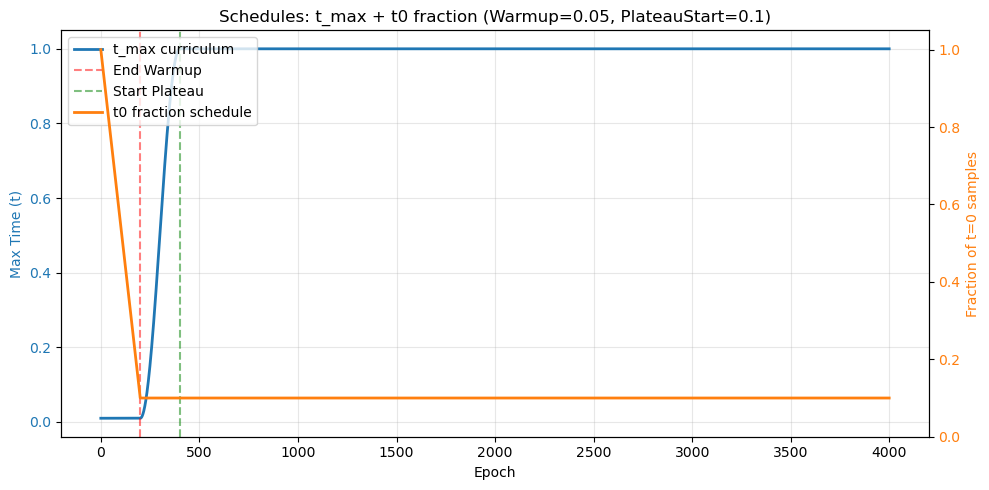

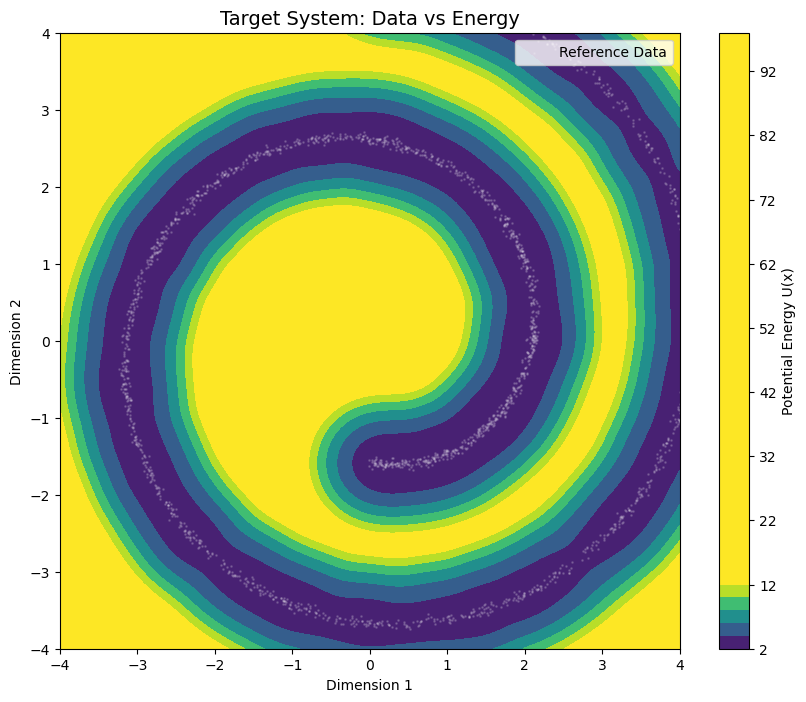

Pre-calculating true energy snapshots for validation...
Computing energy landscapes for times: [0.0, 0.33, 0.66, 1.0]...
  t=0.33: Mean Scale=1.000, New Bandwidth=0.201
  t=0.66: Mean Scale=1.000, New Bandwidth=0.340
  t=1.00: Mean Scale=1.000, New Bandwidth=4.983


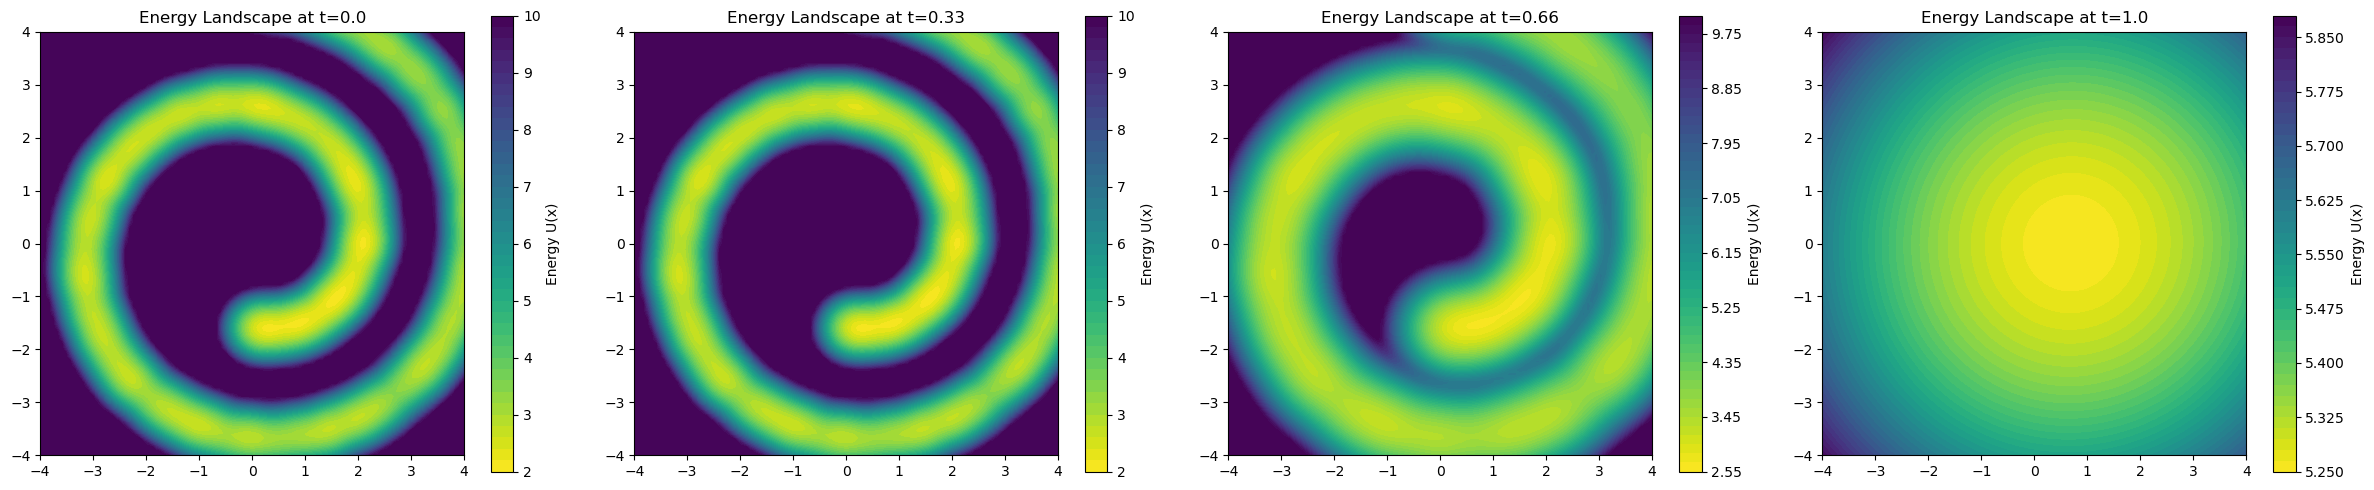

In [63]:
# --- 7. Training Loop ---

noise_data = 0.1

# Initialize Class
target_landscape = SwissRollEnergy(n_samples=2000, noise=noise_data, bandwidth=0.2)

# Hyperparameters
num_epochs = 4000
batch_size = 512 # 1024
learning_rate = 5e-4

warmup = 0.05
plateau = 0.1

# New: t=0 fraction schedule plateau (will linearly decay from 1.0 to this value over warmup)
t0_batch_fraction_plateau = 0.1

horizon_values = [get_time_horizon(e, num_epochs, warmup, plateau) for e in range(num_epochs)]
t0_fraction_values = [get_t0_batch_fraction(e, num_epochs, warmup, t0_batch_fraction_plateau) for e in range(num_epochs)]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(horizon_values, linewidth=2, label="t_max curriculum", color='tab:blue')
ax1.axvline(x=num_epochs*warmup, color='r', linestyle='--', alpha=0.5, label="End Warmup")
ax1.axvline(x=num_epochs*plateau, color='g', linestyle='--', alpha=0.5, label="Start Plateau")
ax1.set_title(f"Schedules: t_max + t0 fraction (Warmup={warmup}, PlateauStart={plateau})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Max Time (t)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Plot t0 fraction schedule on the right axis
ax2 = ax1.twinx()
ax2.plot(t0_fraction_values, linewidth=2, label="t0 fraction schedule", color='tab:orange')
ax2.set_ylabel("Fraction of t=0 samples", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(0.0, 1.05)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Temperature_Training = 1.0
Temperature_Sampling = 1.0

# Visualization Grid
grid_size = 100
x_vis = np.linspace(-4, 4, grid_size)
y_vis = np.linspace(-4, 4, grid_size)
xx, yy = np.meshgrid(x_vis, y_vis)
grid_tensor = torch.tensor(np.column_stack((xx.ravel(), yy.ravel())), dtype=torch.float32).to(device)

plot_dataset_and_energy(target_landscape, device)

# We need the ground truth for t=0, t=0.5, and t=1.0 to calculate differences.
times_to_plot = [0.0, 0.33, 0.66, 1.0] # Use 0.0 instead of 0.0001 for exact dictionary lookup
titles = ["t = 0", "t = 0.33", "t = 0.66", "t = 1.0"]
print("Pre-calculating true energy snapshots for validation...")

# Calculate Intermediate Landscapes
target_landscape.calculate_snapshots(f_xt, g_t, times=times_to_plot)

# Plot
target_landscape.plot_evolution(times=times_to_plot)


Diffusion Training

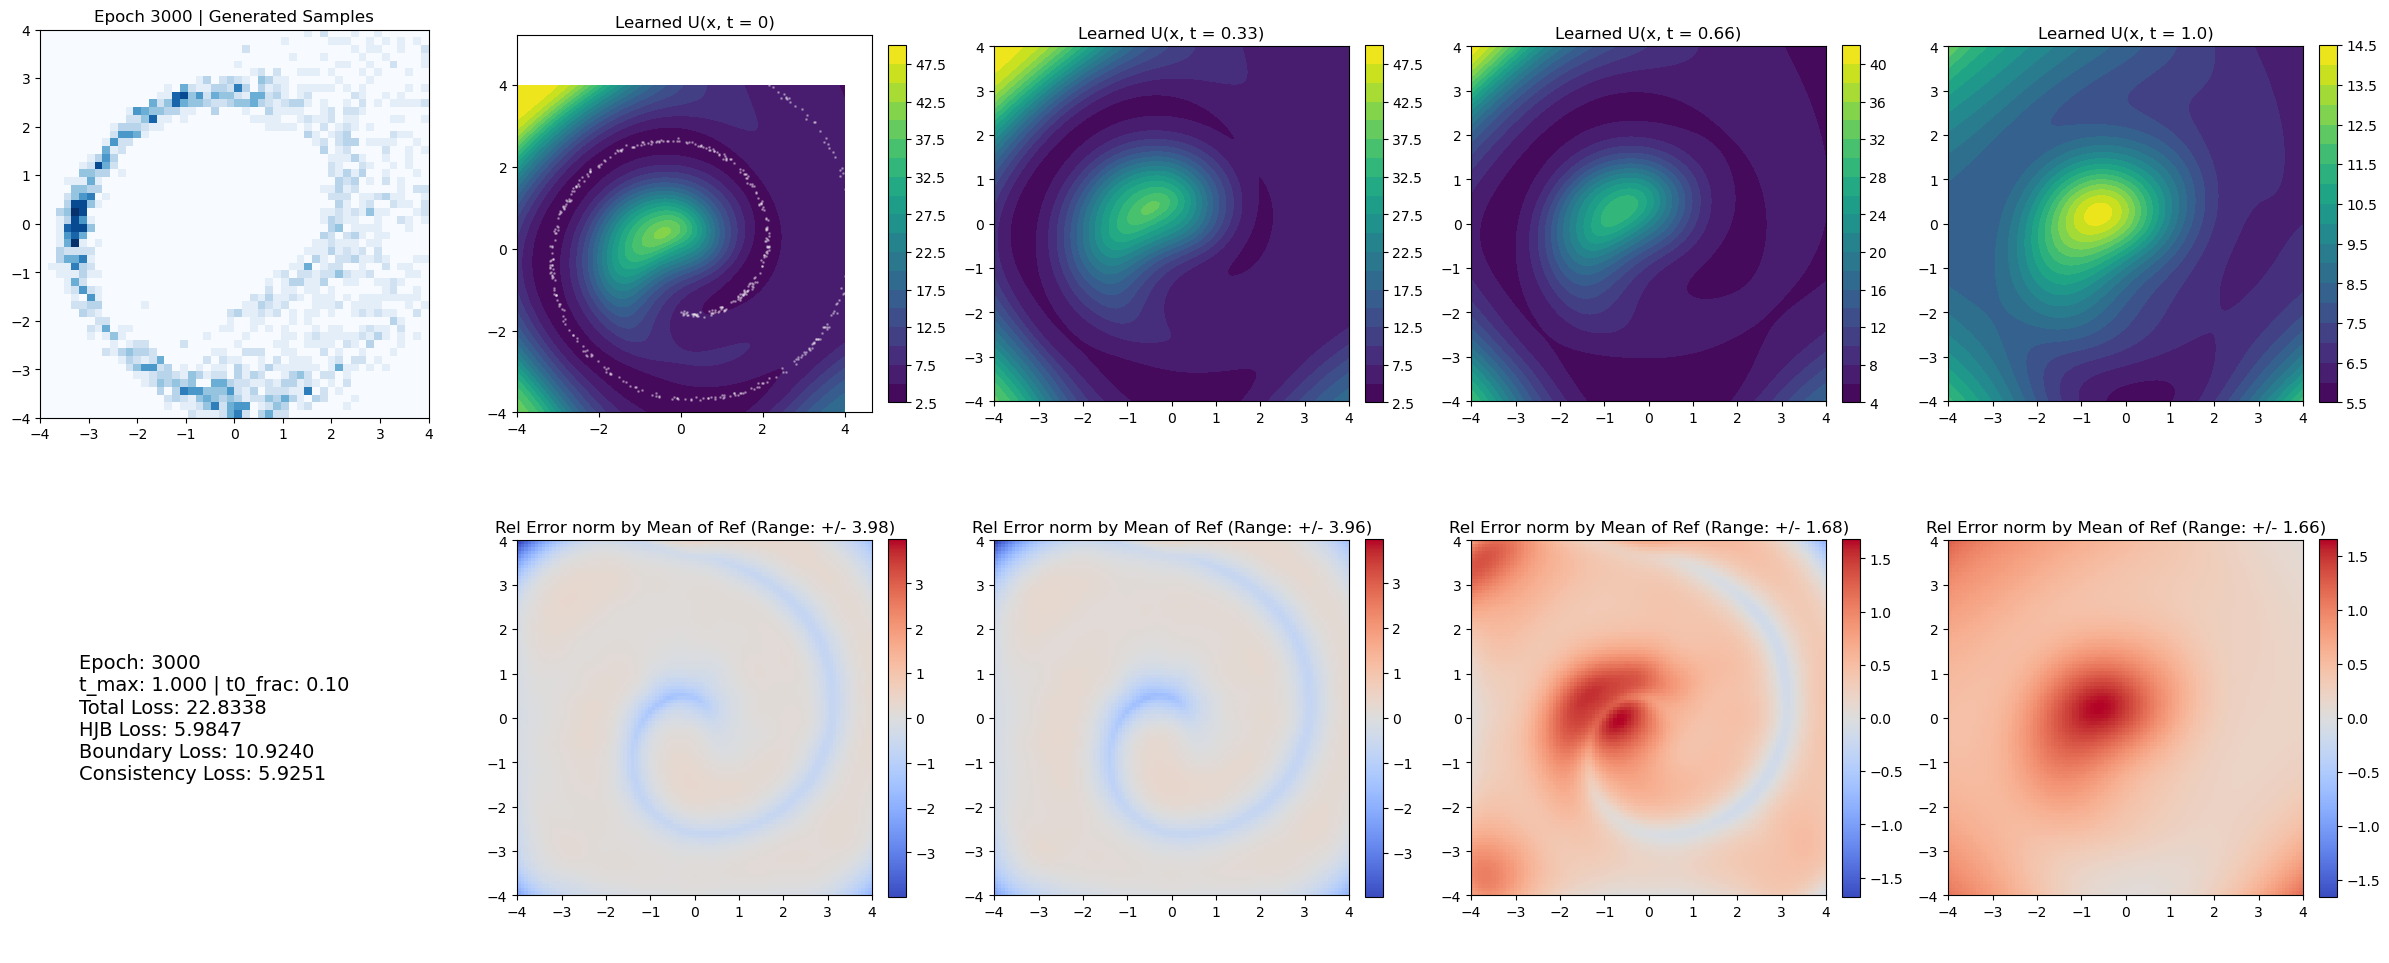

Epoch 3000 | Loss: 22.8338


KeyboardInterrupt: 

In [64]:
# Weights
lambda_hjb = 1.0
lambda_cons = 1.0
lambda_bound = 1.0

# New: t=0 fraction schedule plateau (linearly decays from 1.0 -> this value over warmup)
t0_batch_fraction_plateau = 0.1

# Initialize
model = ScoreNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
sampler = DiffusionSampler(model)

loss_history = []
print("--- Starting 2D HJB Training (Swiss Roll) ---")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # --- Training Step ---
    # 1) Sample Uniform Collocation Points
    x_train = (torch.rand(batch_size, 2).to(device) * 8.0) - 4.0

    # 2) Time horizon curriculum (sample t in [0, t_max])
    t_max = get_time_horizon(epoch, num_epochs, warmup_fraction=warmup, plateau_start_fraction=plateau)
    t_train = torch.rand(batch_size, 1).to(device) * float(t_max)

    # 3) t=0 fraction schedule (subset of the batch is forced to t=0; boundary loss applies only there)
    t0_frac = get_t0_batch_fraction(epoch, num_epochs, warmup_fraction=warmup, t0_batch_fraction_plateau=t0_batch_fraction_plateau)
    n_t0 = int(round(float(t0_frac) * int(batch_size)))
    t0_mask = torch.zeros((batch_size,), device=device, dtype=torch.bool)
    if n_t0 > 0:
        idx = torch.randperm(batch_size, device=device)[:n_t0]
        t0_mask[idx] = True
        t_train[t0_mask] = 0.0

    # 4) Loss
    loss_hjb, loss_cons, loss_bound = calculate_hjb_loss(
        x_train, t_train, model, target_landscape, t0_mask=t0_mask
    )
    loss = (lambda_hjb * loss_hjb) + (lambda_cons * loss_cons) + (lambda_bound * loss_bound)
    loss_history.append(loss.item())

    # 5) Update
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # --- Visualization Step ---
    if epoch % 500 == 0:
        clear_output(wait=True)

        # Create 2 rows: Top for Learned Energy, Bottom for Difference
        fig, axes = plt.subplots(2, 1 + len(times_to_plot), figsize=(24, 10))

        # --- A. Samples (Top-Left) ---
        samples = sampler.sample(2000)
        axes[0, 0].hist2d(samples[:, 0].cpu().numpy(), samples[:, 1].cpu().numpy(),
                          bins=50, range=[[-4, 4], [-4, 4]], cmap='Blues')
        axes[0, 0].set_title(f"Epoch {epoch} | Generated Samples")
        axes[0, 0].set_aspect('equal')

        # --- B. Loss Text (Bottom-Left) ---
        axes[1, 0].axis('off')
        info_text = (f"Epoch: {epoch}\n"
                     f"t_max: {float(t_max):.3f} | t0_frac: {float(t0_frac):.2f}\n"
                     f"Total Loss: {loss.item():.4f}\n"
                     f"HJB Loss: {loss_hjb.item():.4f}\n"
                     f"Boundary Loss: {loss_bound.item():.4f}\n"
                     f"Consistency Loss: {loss_cons.item():.4f}")
        axes[1, 0].text(0.1, 0.5, info_text, fontsize=14, va='center')

        # --- PRE-CALCULATION STEP ---
        plot_data = []
        all_diffs = []

        for i, t_val in enumerate(times_to_plot):
            t_tensor = torch.full((grid_tensor.shape[0], 1), t_val).to(device)
            with torch.no_grad():
                _, u_learned = model(grid_tensor, t_tensor)
                u_true = target_landscape.potential_energy(grid_tensor, t=t_val)

            u_learned_np = u_learned.cpu().numpy().reshape(grid_size, grid_size)
            u_true_np = u_true.cpu().numpy().reshape(grid_size, grid_size)
            u_diff_np = (u_learned_np - u_true_np) / np.mean(u_true_np)  # calculate relative error

            plot_data.append((u_learned_np, u_diff_np))
            all_diffs.append(u_diff_np)

        max_abs_error = [np.abs(d).max() for d in all_diffs]

        # --- C. Plotting ---
        for i, (u_learned_np, u_diff_np) in enumerate(plot_data):
            col_idx = i + 1

            if max_abs_error[i] < 1e-3:
                max_abs_error[i] = 0.01

            # 1. Top Row: Learned Energy
            im1 = axes[0, col_idx].contourf(xx, yy, u_learned_np, levels=20, cmap='viridis')
            axes[0, col_idx].set_title(f"Learned U(x, {titles[i]})")
            axes[0, col_idx].set_aspect('equal')
            fig.colorbar(im1, ax=axes[0, col_idx], fraction=0.046, pad=0.04)

            if i == 0:
                ref_data_cpu = target_landscape.ref_data[:500].cpu().numpy()
                axes[0, col_idx].scatter(ref_data_cpu[:, 0], ref_data_cpu[:, 1],
                                         s=1, c='white', alpha=0.3)

            # 2. Bottom Row: Difference
            im2 = axes[1, col_idx].imshow(u_diff_np,
                                          extent=[-4, 4, -4, 4],
                                          origin='lower',
                                          cmap='coolwarm',
                                          vmin=-max_abs_error[i],
                                          vmax=max_abs_error[i])

            axes[1, col_idx].set_title(f"Rel Error norm by Mean of Ref (Range: +/- {max_abs_error[i]:.2f})")
            axes[1, col_idx].set_aspect('equal')
            fig.colorbar(im2, ax=axes[1, col_idx], fraction=0.046, pad=0.04)

        plt.tight_layout()
        display(fig)
        plt.close()

        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# Final Loss Plot
plot_loss_curve(loss_history)
print("--- Training Finished ---")


FM training

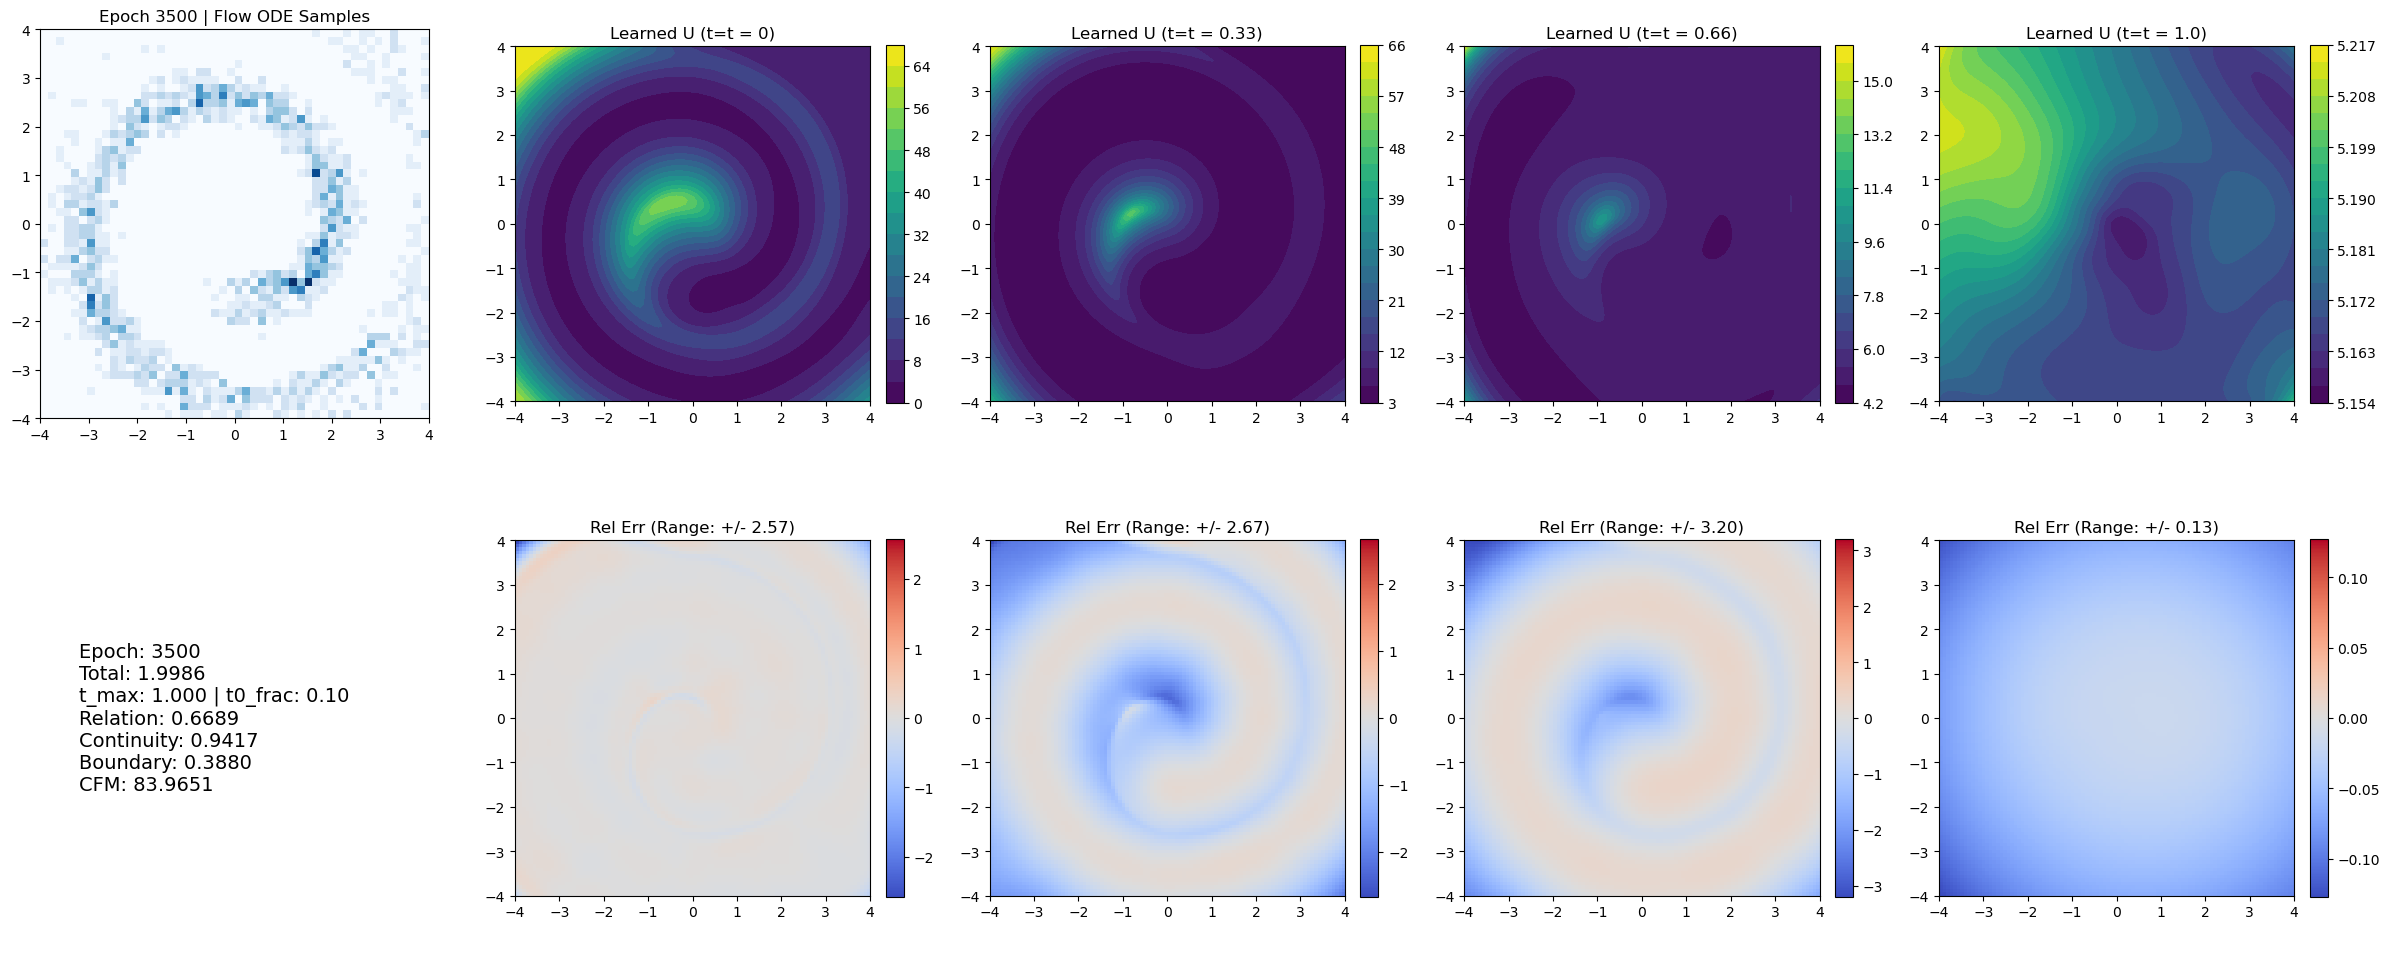

Epoch 3500 | Loss: 1.9986


In [65]:
# --- Setup ---
model = FlowNet().to(device) # Changed to FlowNet
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # Slightly higher LR often helps flow
sampler = FlowODESampler(model) # Changed to FlowODESampler

loss_history = []
print("--- Starting Flow Matching Training (Physics Constraints) ---")

# Weights (Tuning these balances satisfying the PDE vs fitting the Velocity/Energy relation)
w_relation = 1.0
w_continuity = 1.0
w_boundary = 1.0
w_cfm = 0.0

# New: t=0 fraction schedule plateau (linearly decays from 1.0 -> this value over warmup)
t0_batch_fraction_plateau = 0.1

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # --- Get Time Horizon (Curriculum) ---
    t_max = get_time_horizon(epoch, num_epochs, warmup_fraction=warmup, plateau_start_fraction=plateau)

    # 1. Sample Data
    x_train = (torch.rand(batch_size, 2).to(device) * 8.0) - 4.0
    # Sample from [0, t_max]
    t_train = torch.rand(batch_size, 1).to(device) * float(t_max)

    # t=0 fraction schedule (subset forced to t=0; boundary loss applies only there)
    t0_frac = get_t0_batch_fraction(epoch, num_epochs, warmup_fraction=warmup, t0_batch_fraction_plateau=t0_batch_fraction_plateau)
    n_t0 = int(round(float(t0_frac) * int(batch_size)))
    t0_mask = torch.zeros((batch_size,), device=device, dtype=torch.bool)
    if n_t0 > 0:
        idx = torch.randperm(batch_size, device=device)[:n_t0]
        t0_mask[idx] = True
        t_train[t0_mask] = 0.0

    # CFM loss
    X, _ = make_swiss_roll(n_samples=batch_size, noise=noise_data)
    X = X[:, [0, 2]] / 3.0  # Project to 2D (x, z) and scale
    X = torch.tensor(X, dtype=torch.float32).to(device)
    loss_cfm = calculate_cfm_loss(t_train, model, X)

    # 2. Calculate Flow Loss
    loss_rel, loss_cont, loss_bound = calculate_flow_matching_loss(
        x_train, t_train, model, target_landscape, t0_mask=t0_mask
    )

    loss = (w_relation * loss_rel) + (w_continuity * loss_cont) + (w_boundary * loss_bound) + (w_cfm * loss_cfm)

    loss_history.append(loss.item())

    # 3. Update
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # --- Visualization (Same as before) ---
    if epoch % 500 == 0:
        clear_output(wait=True)

        fig, axes = plt.subplots(2, 1 + len(times_to_plot), figsize=(24, 10))

        # A. Samples
        samples = sampler.sample(2000)
        axes[0, 0].hist2d(samples[:, 0].cpu().numpy(), samples[:, 1].cpu().numpy(),
                          bins=50, range=[[-4, 4], [-4, 4]], cmap='Blues')
        axes[0, 0].set_title(f"Epoch {epoch} | Flow ODE Samples")
        axes[0, 0].set_aspect('equal')

        # B. Info
        axes[1, 0].axis('off')
        info_text = (f"Epoch: {epoch}\nTotal: {loss.item():.4f}\n"
                     f"t_max: {float(t_max):.3f} | t0_frac: {float(t0_frac):.2f}\n"
                     f"Relation: {loss_rel.item():.4f}\n"
                     f"Continuity: {loss_cont.item():.4f}\n"
                     f"Boundary: {loss_bound.item():.4f}\n"
                     f"CFM: {loss_cfm.item():.4f}")
        axes[1, 0].text(0.1, 0.5, info_text, fontsize=14, va='center')

        # C. Energy Comparison
        plot_data = []
        all_diffs = []
        for i, t_val in enumerate(times_to_plot):
            t_tensor = torch.full((grid_tensor.shape[0], 1), t_val).to(device)
            with torch.no_grad():
                _, u_learned = model(grid_tensor, t_tensor) # Only change here is ignoring first return (v)
                u_true = target_landscape.potential_energy(grid_tensor, t=t_val)

            u_learned_np = u_learned.cpu().numpy().reshape(grid_size, grid_size)
            u_true_np = u_true.cpu().numpy().reshape(grid_size, grid_size)
            u_diff_np = (u_learned_np - u_true_np) / np.mean(u_true_np)
            plot_data.append((u_learned_np, u_diff_np))
            all_diffs.append(u_diff_np)

        max_abs_error = [np.abs(d).max() for d in all_diffs]

        for i, (u_learned_np, u_diff_np) in enumerate(plot_data):
            col_idx = i + 1
            if max_abs_error[i] < 1e-3: max_abs_error[i] = 0.01

            im1 = axes[0, col_idx].contourf(xx, yy, u_learned_np, levels=20, cmap='viridis')
            axes[0, col_idx].set_title(f"Learned U (t={titles[i]})")
            axes[0, col_idx].set_aspect('equal')
            fig.colorbar(im1, ax=axes[0, col_idx], fraction=0.046, pad=0.04)

            im2 = axes[1, col_idx].imshow(u_diff_np, extent=[-4, 4, -4, 4], origin='lower',
                                          cmap='coolwarm', vmin=-max_abs_error[i], vmax=max_abs_error[i])
            axes[1, col_idx].set_title(f"Rel Err (Range: +/- {max_abs_error[i]:.2f})")
            axes[1, col_idx].set_aspect('equal')
            fig.colorbar(im2, ax=axes[1, col_idx], fraction=0.046, pad=0.04)

        plt.tight_layout()
        display(fig)
        plt.close()
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")